# 04 — Normalizing Flows (MAF)

Trains a per-entity **Masked Autoregressive Flow** on the preprocessed NASA SMAP/MSL windows.

- Each individual timestep (shape `(n_channels,)`) is treated as a sample
- The flow learns the distribution of **normal** timesteps from training data
- Anomaly score at each timestep = `-log_likelihood(timestep_vector)`
- A rolling mean (window=20) is applied post-hoc to enforce temporal coherence
- Outputs `results/flows/{entity_id}_{val,test}_scores.npy` ready for threshold-based evaluation

In [29]:
import torch
import normflows as nf
import numpy as np
import json
from pathlib import Path
from tqdm.auto import tqdm
import optuna
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

DATA_DIR = Path("data/processed")
RESULTS_DIR = Path("results/flows")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

N_EPOCHS = 50
BATCH_SIZE = 512
OPTUNA_TRIALS = 50
OPTUNA_ENTITIES = 10

print(f"Device: {DEVICE}")

Device: mps


In [30]:
with open(DATA_DIR / "metadata.json") as f:
    metadata = json.load(f)

ENTITIES = metadata["entities"]
N_CHANNELS = metadata["n_channels"]
WINDOW_SIZE = metadata["window_size"]

print(f"Entities: {len(ENTITIES)}, window_size: {WINDOW_SIZE}")


def build_maf(n_channels, num_flows, hidden_units):
    flows = []
    for _ in range(num_flows):
        flows.append(nf.flows.AutoregressiveRationalQuadraticSpline(
            num_input_channels=n_channels,
            num_blocks=2,
            num_hidden_channels=hidden_units,
        ))
        if n_channels > 1:
            flows.append(nf.flows.LULinearPermute(n_channels))
    base = nf.distributions.DiagGaussian(n_channels, trainable=False)
    model = nf.NormalizingFlow(q0=base, flows=flows)
    return model

Entities: 82, window_size: 100


## Why Per-Timestep

MAF scales poorly with input dimension because the autoregressive structure requires one pass per dimension during sampling, and the number of parameters grows quadratically with the feature size. The SMAP/MSL entities have at most ~55 channels, so treating each timestep as an independent sample keeps the input dimension small and training tractable. Temporal context is not discarded entirely — it is recovered post-hoc via a rolling-mean smoothing of the per-timestep scores.

## Training Utilities

In [31]:
def train_flow(model, train_data, n_epochs, lr, batch_size, device):
    train_tensor = torch.tensor(train_data, dtype=torch.float32)
    loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses = []

    model.to(device)
    model.train()
    for _ in range(n_epochs):
        epoch_loss = 0.0
        for (x,) in loader:
            x = x.to(device)
            optimizer.zero_grad()
            loss = -model.log_prob(x).mean()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * x.size(0)
        train_losses.append(epoch_loss / len(loader.dataset))

    return model, train_losses


def compute_flow_scores(model, data, device, batch_size=512, smooth_window=20):
    data_tensor = torch.tensor(data, dtype=torch.float32)
    loader = DataLoader(TensorDataset(data_tensor), batch_size=batch_size, shuffle=False)
    model.eval()
    scores = []
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            log_p = model.log_prob(x)
            scores.append((-log_p).cpu().numpy())
    raw = np.concatenate(scores)
    if smooth_window > 1:
        smoothed = np.convolve(raw, np.ones(smooth_window) / smooth_window, mode="same")
    else:
        smoothed = raw
    return smoothed.astype(np.float32)

## Hyperparameter Tuning with Optuna

In [32]:
def optuna_objective(trial, entity_id, n_channels):
    num_flows   = trial.suggest_categorical("num_flows", [2, 3, 4, 6])
    hidden_units = trial.suggest_categorical("hidden_units", [32, 64, 128])
    lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    smooth_window = trial.suggest_categorical("smooth_window", [5, 10, 20, 40])
    n_epochs_trial = 10

    train_windows = np.load(DATA_DIR / f"{entity_id}_train.npy")
    train_data = train_windows.reshape(-1, n_channels)[::5]

    val_windows = np.load(DATA_DIR / f"{entity_id}_val.npy")
    if val_windows.ndim < 3 or len(val_windows) == 0:
        raise optuna.exceptions.TrialPruned()
    val_data = val_windows[:, -1, :]

    model = build_maf(n_channels, num_flows, hidden_units)
    model, _ = train_flow(model, train_data, n_epochs_trial, lr, BATCH_SIZE, DEVICE)

    val_tensor = torch.tensor(val_data, dtype=torch.float32).to(DEVICE)
    model.eval()
    with torch.no_grad():
        val_loss = -model.log_prob(val_tensor).mean().item()

    return val_loss

In [33]:
import csv
_labels_map = {}
with open('labeled_anomalies.csv') as _f:
    for _row in csv.DictReader(_f):
        _labels_map[_row['chan_id']] = _row['spacecraft']

smap_pool = [e for e in ENTITIES if _labels_map.get(e) == 'SMAP'][:OPTUNA_ENTITIES]
msl_pool  = [e for e in ENTITIES if _labels_map.get(e) == 'MSL'][:OPTUNA_ENTITIES]
print(f"Optuna: {len(smap_pool)} encji SMAP + {len(msl_pool)} encji MSL")

optuna.logging.set_verbosity(optuna.logging.WARNING)
valid_num_flows    = [2, 3, 4, 6]
valid_hidden_units = [32, 64, 128]
valid_smooth_windows = [5, 10, 20, 40]

def run_optuna_group(entity_pool, group_name):
    all_params = []
    for entity_id in tqdm(entity_pool, desc=f"Optuna {group_name}"):
        nc = N_CHANNELS[entity_id]
        study = optuna.create_study(direction="minimize")
        study.optimize(
            lambda trial, eid=entity_id, nc=nc: optuna_objective(trial, eid, nc),
            n_trials=OPTUNA_TRIALS,
        )
        all_params.append(study.best_params)
        print(f"  {entity_id}: loss={study.best_value:.4f}, params={study.best_params}")
    avg_flows  = np.mean([p["num_flows"]    for p in all_params])
    avg_hidden = np.mean([p["hidden_units"] for p in all_params])
    avg_smooth = np.mean([p["smooth_window"] for p in all_params])
    return {
        "num_flows":    min(valid_num_flows,    key=lambda v: abs(v - avg_flows)),
        "hidden_units": min(valid_hidden_units, key=lambda v: abs(v - avg_hidden)),
        "lr":           float(np.exp(np.mean([np.log(p["lr"]) for p in all_params]))),
        "smooth_window": min(valid_smooth_windows, key=lambda v: abs(v - avg_smooth)),
    }

best_params_smap = run_optuna_group(smap_pool, "SMAP")
with open(RESULTS_DIR / "best_params_smap.json", "w") as f:
    json.dump(best_params_smap, f, indent=2)
print(f"\nSMAP: {best_params_smap}")

best_params_msl = run_optuna_group(msl_pool, "MSL")
with open(RESULTS_DIR / "best_params_msl.json", "w") as f:
    json.dump(best_params_msl, f, indent=2)
print(f"MSL:  {best_params_msl}")

Optuna: 10 encji SMAP + 10 encji MSL


Optuna SMAP:   0%|          | 0/10 [00:00<?, ?it/s]

  A-1: loss=-77.2873, params={'num_flows': 2, 'hidden_units': 32, 'lr': 0.0011071011271858076, 'smooth_window': 20}
  A-2: loss=-61.5723, params={'num_flows': 2, 'hidden_units': 64, 'lr': 0.0018039829756020798, 'smooth_window': 10}
  A-3: loss=-74.9630, params={'num_flows': 2, 'hidden_units': 128, 'lr': 0.00047575432908255466, 'smooth_window': 40}
  A-4: loss=-69.1340, params={'num_flows': 2, 'hidden_units': 128, 'lr': 0.0005653136651480496, 'smooth_window': 40}
  A-5: loss=-21.0816, params={'num_flows': 2, 'hidden_units': 32, 'lr': 0.0043667321892108864, 'smooth_window': 20}
  A-6: loss=415.5443, params={'num_flows': 3, 'hidden_units': 128, 'lr': 0.00048189261174696893, 'smooth_window': 5}
  A-7: loss=-84.4620, params={'num_flows': 2, 'hidden_units': 128, 'lr': 0.0006209155568231417, 'smooth_window': 5}
  A-8: loss=-46.8091, params={'num_flows': 2, 'hidden_units': 128, 'lr': 0.008006654374947334, 'smooth_window': 40}
  A-9: loss=-49.3471, params={'num_flows': 2, 'hidden_units': 64, 'l

Optuna MSL:   0%|          | 0/10 [00:00<?, ?it/s]

  C-1: loss=-150.7509, params={'num_flows': 2, 'hidden_units': 32, 'lr': 0.0019540579761519877, 'smooth_window': 10}
  C-2: loss=-116.2802, params={'num_flows': 2, 'hidden_units': 64, 'lr': 0.007600554861724947, 'smooth_window': 40}
  D-14: loss=-170.4983, params={'num_flows': 2, 'hidden_units': 64, 'lr': 0.0003943609166999119, 'smooth_window': 20}
  D-15: loss=-133.7199, params={'num_flows': 2, 'hidden_units': 64, 'lr': 0.0007608204240815184, 'smooth_window': 5}
  D-16: loss=-141.3951, params={'num_flows': 2, 'hidden_units': 64, 'lr': 0.006239542176298282, 'smooth_window': 5}
  F-4: loss=-158.6123, params={'num_flows': 3, 'hidden_units': 32, 'lr': 0.0005727768874245789, 'smooth_window': 10}
  F-5: loss=-162.0841, params={'num_flows': 2, 'hidden_units': 32, 'lr': 0.001083231465611706, 'smooth_window': 10}
  F-7: loss=-147.8894, params={'num_flows': 2, 'hidden_units': 64, 'lr': 0.0008271865234265087, 'smooth_window': 20}
  F-8: loss=-148.5327, params={'num_flows': 2, 'hidden_units': 64,

## Training on All Entities

SMAP params: {'num_flows': 2, 'hidden_units': 64, 'lr': 0.0014211543203655607, 'smooth_window': 20}
MSL  params: {'num_flows': 2, 'hidden_units': 64, 'lr': 0.0019328303289585266, 'smooth_window': 10}


Training all entities:   0%|          | 0/82 [00:00<?, ?it/s]

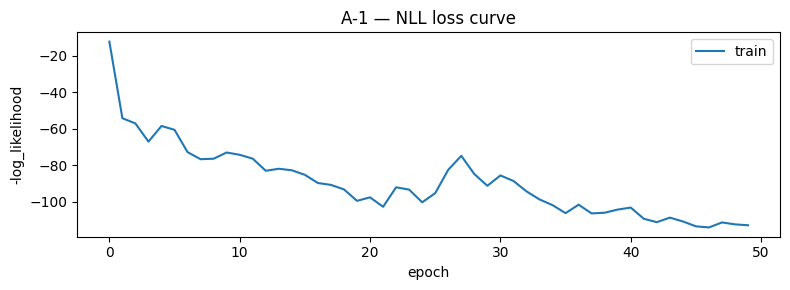

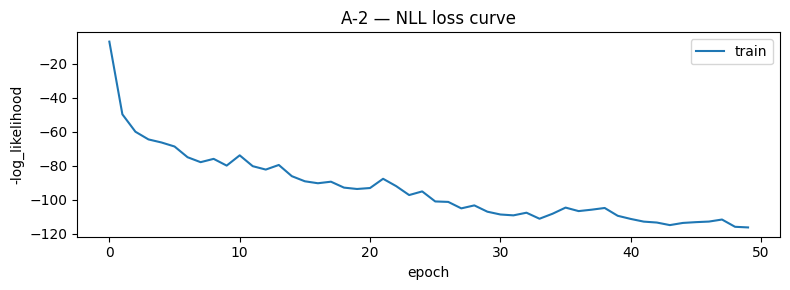

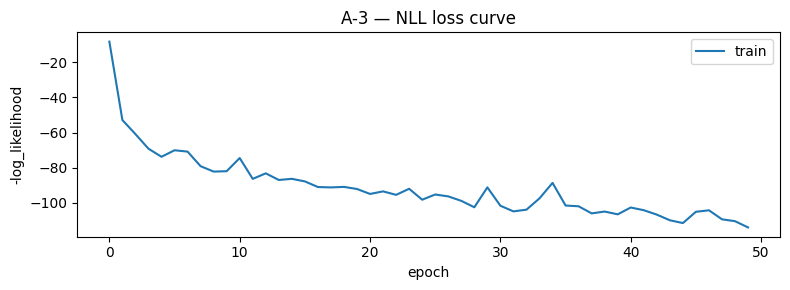

In [34]:
import csv as _csv
_lmap = {}
with open('labeled_anomalies.csv') as _f:
    for _row in _csv.DictReader(_f):
        _lmap[_row['chan_id']] = _row['spacecraft']

with open(RESULTS_DIR / "best_params_smap.json") as f:
    best_params_smap = json.load(f)
with open(RESULTS_DIR / "best_params_msl.json") as f:
    best_params_msl = json.load(f)

print("SMAP params:", best_params_smap)
print("MSL  params:", best_params_msl)

trained_models = {}

for idx, eid in enumerate(tqdm(ENTITIES, desc="Training all entities")):
    nc = N_CHANNELS[eid]
    train_windows = np.load(DATA_DIR / f"{eid}_train.npy")
    train_data = train_windows.reshape(-1, nc)

    bp = best_params_msl if _lmap.get(eid) == 'MSL' else best_params_smap
    model = build_maf(nc, bp["num_flows"], bp["hidden_units"])
    model, train_losses = train_flow(model, train_data, N_EPOCHS, bp["lr"], BATCH_SIZE, DEVICE)

    torch.save(model.state_dict(), RESULTS_DIR / f"{eid}_model.pt")
    trained_models[eid] = model

    if idx < 3:
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(train_losses, label="train")
        ax.set_title(f"{eid} — NLL loss curve")
        ax.set_xlabel("epoch")
        ax.set_ylabel("-log_likelihood")
        ax.legend()
        plt.tight_layout()
        plt.show()

## Anomaly Score Computation

In [35]:
import csv as _csv
_lmap = {}
with open('labeled_anomalies.csv') as _f:
    for _row in _csv.DictReader(_f):
        _lmap[_row['chan_id']] = _row['spacecraft']

with open(RESULTS_DIR / "best_params_smap.json") as f:
    best_params_smap = json.load(f)
with open(RESULTS_DIR / "best_params_msl.json") as f:
    best_params_msl = json.load(f)

print("SMAP params:", best_params_smap)
print("MSL  params:", best_params_msl)

for entity_id in tqdm(ENTITIES, desc="Computing scores"):
    nc = N_CHANNELS[entity_id]

    bp = best_params_msl if _lmap.get(entity_id) == 'MSL' else best_params_smap
    model = build_maf(nc, bp["num_flows"], bp["hidden_units"])
    state = torch.load(RESULTS_DIR / f"{entity_id}_model.pt", map_location=DEVICE)
    model.load_state_dict(state)
    model.to(DEVICE)

    test_windows = np.load(DATA_DIR / f"{entity_id}_test.npy")
    test_last = test_windows[:, -1, :]
    test_scores = compute_flow_scores(model, test_last, DEVICE, smooth_window=bp["smooth_window"])
    np.save(RESULTS_DIR / f"{entity_id}_test_scores.npy", test_scores)

    val_windows = np.load(DATA_DIR / f"{entity_id}_val.npy")
    if val_windows.ndim < 3 or len(val_windows) == 0:
        np.save(RESULTS_DIR / f"{entity_id}_val_scores.npy", np.array([], dtype=np.float32))
        continue
    val_last = val_windows[:, -1, :]
    val_scores = compute_flow_scores(model, val_last, DEVICE, smooth_window=bp["smooth_window"])
    np.save(RESULTS_DIR / f"{entity_id}_val_scores.npy", val_scores)

    if entity_id == ENTITIES[0]:
        print(f"{entity_id} — test scores: min={test_scores.min():.4f}, max={test_scores.max():.4f}, mean={test_scores.mean():.4f}")

print("Scores saved for all entities.")

SMAP params: {'num_flows': 2, 'hidden_units': 64, 'lr': 0.0014211543203655607, 'smooth_window': 20}
MSL  params: {'num_flows': 2, 'hidden_units': 64, 'lr': 0.0019328303289585266, 'smooth_window': 10}


Computing scores:   0%|          | 0/82 [00:00<?, ?it/s]

A-1 — test scores: min=-123.8803, max=6.5237, mean=-114.5698
Scores saved for all entities.


## Score Distribution (Sample Entity)

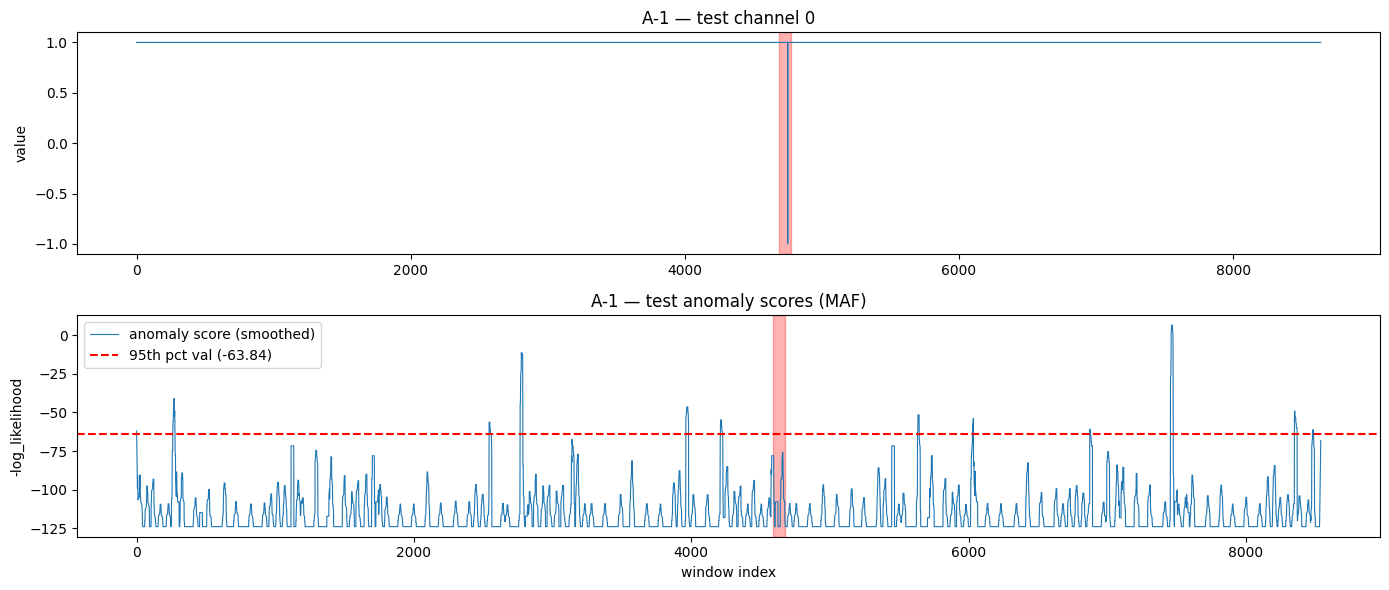

In [36]:
import pandas as pd

sample_id = ENTITIES[0]
test_scores = np.load(RESULTS_DIR / f"{sample_id}_test_scores.npy")
val_scores = np.load(RESULTS_DIR / f"{sample_id}_val_scores.npy")

labels_df = pd.read_csv("labeled_anomalies.csv")
entity_labels = labels_df[labels_df["chan_id"] == sample_id]

test_raw = np.load(Path("data") / "test" / f"{sample_id}.npy")
if test_raw.ndim == 1:
    test_raw = test_raw.reshape(-1, 1)

threshold = np.percentile(val_scores, 95)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

ax0 = axes[0]
ax0.plot(test_raw[:, 0], linewidth=0.8)
for _, row in entity_labels.iterrows():
    for seg in json.loads(row["anomaly_sequences"]):
        ax0.axvspan(seg[0], seg[1], alpha=0.3, color="red")
ax0.set_title(f"{sample_id} — test channel 0")
ax0.set_ylabel("value")

ax1 = axes[1]
n_scores = len(test_scores)
ax1.plot(test_scores, linewidth=0.8, label="anomaly score (smoothed)")
ax1.axhline(threshold, color="red", linestyle="--", label=f"95th pct val ({threshold:.2f})")
for _, row in entity_labels.iterrows():
    for seg in json.loads(row["anomaly_sequences"]):
        score_start = max(0, seg[0] - WINDOW_SIZE)
        score_end = min(n_scores, max(0, seg[1] - WINDOW_SIZE))
        if score_end > score_start:
            ax1.axvspan(score_start, score_end, alpha=0.3, color="red")
ax1.set_title(f"{sample_id} — test anomaly scores (MAF)")
ax1.set_ylabel("-log_likelihood")
ax1.set_xlabel("window index")
ax1.legend()

plt.tight_layout()
plt.show()